## Verify the Environment

Check that Python and the required machine learning libraries are working correctly.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-Learn:", sklearn.__version__)

Python: 3.14.4 (main, Aug 20 2026, 10:41:58) [GCC 15.2.0]
NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.1
Scikit-Learn: 1.9.0


## Fetch the MNIST Dataset

Load the MNIST handwritten digit dataset from OpenML.

### Data Source

The MNIST dataset is obtained from OpenML using Scikit-Learn's `fetch_openml()` function, following the approach used in Géron's *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*.

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

x = mnist["data"]
y = mnist["target"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (70000, 784)
y shape: (70000,)


## Inspect the Dataset

Check the size, data type, and structure of the MNIST dataset.

In [4]:
print("x shape:", x.shape)
print("y shape:", y.shape)

print("x data type:", x.dtype)
print("y data type:", y.dtype)

x shape: (70000, 784)
y shape: (70000,)
x data type: int64
y data type: object


#### Dataset Structure

The MNIST dataset contains 70,000 handwritten digit images. Each image is 28 × 28 pixels, giving 784 pixel features. `x` contains the pixel data, while `y` contains the corresponding digit labels.

## Analyze the Labels

Check the different digit labels and how many images belong to each digit.

In [5]:
print(np.unique(y, return_counts=True))

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object), array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]))


#### Label Distribution

The MNIST dataset contains 10 digit classes, from 0 to 9. The number of images varies slightly between the classes, but the dataset is relatively balanced.

## Visualize an MNIST Image

Display one handwritten digit from the dataset.

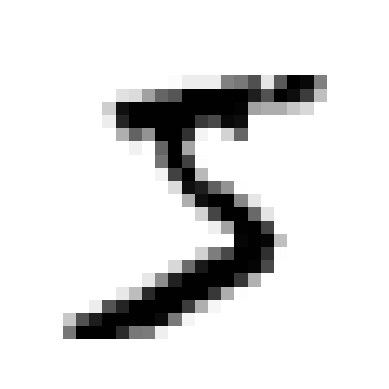

Label: 5


In [6]:
import matplotlib.pyplot as plt

plt.imshow(x[0].reshape(28, 28), cmap="binary")
plt.axis("off")
plt.show()

print("Label:", y[0])

## Inspect Pixel Values

Examine the pixel values that represent the handwritten digit.

In [7]:
print(x[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

#### Observations

The images are represented as numerical pixel values. Each image contains 784 pixels arranged in a 28×28 grid, with different pixel values forming the shape of each handwritten digit.

## Visualize Multiple MNIST Images

Display several handwritten digits from the MNIST dataset to observe different examples.

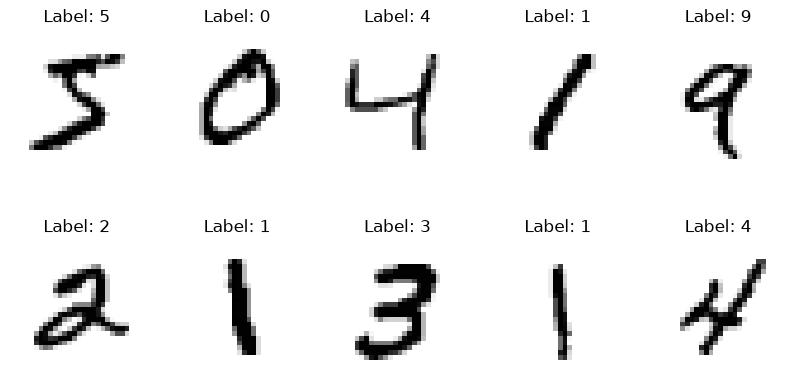

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x[i].reshape(28, 28), cmap="binary")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")

plt.show()

## Split the Dataset

Separate the MNIST dataset into training data and test data.

The first 60,000 images will be used for training, while the last 10,000 images will be kept for final testing.

In [9]:
x_train = x[:60000]
y_train = y[:60000]

x_test = x[60000:]
y_test = y[60000:]

## Check the Dataset Shapes

Check the number of images and labels in the training and test sets.

In [10]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (60000, 784)
y_train: (60000,)
x_test: (10000, 784)
y_test: (10000,)


## Create a Validation Set

Set aside part of the training data for validation while keeping the test data untouched.

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=10000,
    random_state=42
)

## Check the Training and Validation Sets

Check the shapes of the training and validation data after splitting.

In [12]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (50000, 784)
y_train: (50000,)
x_val: (10000, 784)
y_val: (10000,)
x_test: (10000, 784)
y_test: (10000,)


## Create a 5 vs. Not-5 Target

   BINARY CLASSIFICATION

Create a binary target where `True` represents the digit 5 and `False` represents every other digit.

In [13]:
y_train_5 = (y_train == "5")
y_val_5 = (y_val == "5")
y_test_5 = (y_test == "5")

In [14]:
print("5:", y_train_5.sum())
print("Not 5:", (~y_train_5).sum())

5: 4502
Not 5: 45498


## Train an SGD Classifier

Train a Stochastic Gradient Descent (SGD) classifier to distinguish between the digit 5 and all other digits.

In [15]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(x_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

## Make Predictions with the SGD Classifier

Use the trained SGD classifier to predict whether images are 5 or not 5.

In [16]:
y_train_pred = sgd_clf.predict(x_train)

## Compare Predictions with Actual Labels

Compare the model's predictions with the actual 5 vs. not-5 labels.

In [17]:
for i in range(10):
    print(
        f"Actual: {y_train_5[i]} | Predicted: {y_train_pred[i]}"
    )

Actual: False | Predicted: False
Actual: True | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False
Actual: False | Predicted: False


#### Measure accuracy

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_train_5, y_train_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97144


### Evaluate Accuracy with Cross-Validation

Use cross-validation to evaluate the SGD classifier on different parts of the training data.

cv=3 means The 50,000 training samples are divided into 3 folds.

In [19]:
from sklearn.model_selection import cross_val_score

cross_val_score(
    sgd_clf,
    x_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

array([0.96658067, 0.95608088, 0.93375735])

### Accuracy Can Be Misleading

Create a classifier that always predicts that an image is not a 5 to demonstrate the limitation of accuracy.

Create a simple classifier that always predicts `False`, meaning the image is not a 5.

In [20]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, x, y=None):
        return self

    def predict(self, x):
        return np.zeros((len(x),), dtype=bool)

In [21]:
never_5_clf = Never5Classifier()

cross_val_score(
    never_5_clf,
    x_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

array([0.90796184, 0.9098818 , 0.91203648])

The Never-5 classifier achieves about 91% accuracy by always predicting that an image is not a 5. This shows that accuracy alone can be misleading when the classes are imbalanced.

## Confusion Matrix

Use a confusion matrix to see how the classifier distinguishes between 5 and not 5.

In [22]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    x_train,
    y_train_5,
    cv=3
)

In [23]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[44337,  1161],
       [ 1232,  3270]])

#### Confusion Matrix Observation

The confusion matrix shows the correct and incorrect predictions made by the SGD classifier.

| Actual / Predicted | Not 5 | 5 |
|---|---:|---:|
| Not 5 | 44,337 (TN) | 1,161 (FP) |
| 5 | 1,232 (FN) | 3,270 (TP) |

- **TN (True Negative) = 44,337:** The image was not 5 and was correctly predicted as not 5.
- **FP (False Positive) = 1,161:** The image was not 5 but was incorrectly predicted as 5.
- **FN (False Negative) = 1,232:** The image was 5 but was incorrectly predicted as not 5.
- **TP (True Positive) = 3,270:** The image was 5 and was correctly predicted as 5.

In [24]:
from sklearn.metrics import precision_score

precision = precision_score(y_train_5, y_train_pred)

print("Precision:", precision)

Precision: 0.7379823967501693


In [25]:
from sklearn.metrics import recall_score

recall = recall_score(y_train_5, y_train_pred)

print("Recall:", recall)

Recall: 0.7263438471790316


In [26]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)

print("F1 Score:", f1)

F1 Score: 0.732116870032464


## Precision/Recall Trade-off

A classification model does not always use the same decision threshold.

Changing the threshold affects precision and recall:

- Increasing the threshold usually increases precision but decreases recall.
- Decreasing the threshold usually increases recall but decreases precision.

Therefore, there is a trade-off between precision and recall.

In [27]:
y_scores = sgd_clf.decision_function(x_train)

print(y_scores[:10])

[ -5423.57888588  -3814.4764374  -12318.40155331 -12315.08733106
 -11603.99088146 -13736.30973649 -19070.82313804  -7176.94509387
  -5835.05985518 -16388.17138547]


In [28]:
y_train_pred_0 = (y_scores >= 0)

print(y_train_pred_0[:10])

[False False False False False False False False False False]


In [29]:
y_train_pred_5000 = (y_scores >= 5000)

print(y_train_pred_5000[:10])

[False False False False False False False False False False]


In [30]:
print("Minimum score:", y_scores.min())
print("Maximum score:", y_scores.max())

Minimum score: -116164.00829998068
Maximum score: 41367.925350093


In [31]:
y_train_pred_20000 = (y_scores >= 20000)

print("Predicted as 5:", y_train_pred_20000.sum())
print("Predicted as Not 5:", (~y_train_pred_20000).sum())

Predicted as 5: 74
Predicted as Not 5: 49926


In [32]:
precision_20000 = precision_score(y_train_5, y_train_pred_20000)
recall_20000 = recall_score(y_train_5, y_train_pred_20000)

print("Precision:", precision_20000)
print("Recall:", recall_20000)

Precision: 0.9864864864864865
Recall: 0.016215015548645045


#### Precision/Recall Trade-off Observation

When the decision threshold was increased to **20,000**, precision increased to **98.65%**, while recall decreased to **1.62%**.

This shows the precision/recall trade-off:

- A higher threshold makes the classifier more strict, increasing precision.
- A higher threshold also causes the classifier to miss more actual 5s, decreasing recall.

## Precision-Recall Curve

The precision-recall curve shows how precision and recall change as the decision threshold changes.

It helps us understand the trade-off between precision and recall and choose an appropriate threshold for the classifier.

In [33]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    y_scores
)

print("Number of thresholds:", len(thresholds))

Number of thresholds: 50000


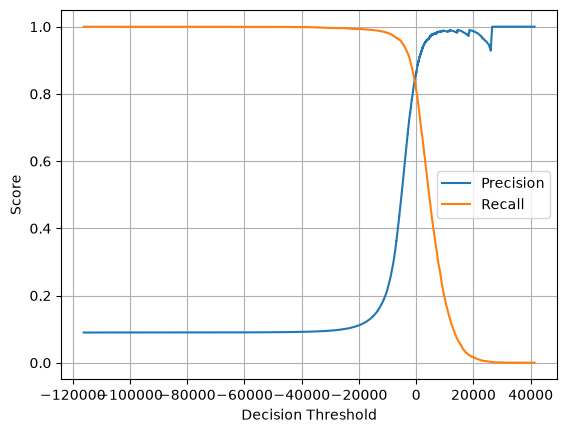

In [34]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

The graph shows the relationship between the decision threshold, precision, and recall.

As the decision threshold increases, **precision generally increases**, while **recall decreases**.

This demonstrates the **precision/recall trade-off**. A higher threshold makes the classifier more strict when predicting an image as 5, which reduces false positives but causes the model to miss more actual 5s.

## Choose a Threshold for a Desired Precision

Instead of choosing a decision threshold arbitrarily, we can choose a threshold that achieves a desired precision.

For example, we can find a threshold that gives approximately **90% precision** and then check the corresponding recall.

In [35]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

print("Threshold:", threshold_90_precision)

Threshold: 873.2825736187883


In [36]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

print("Predicted as 5:", y_train_pred_90.sum())

Predicted as 5: 3797


In [37]:
recall_90 = recall_score(y_train_5, y_train_pred_90)

print("Recall at 90% precision:", recall_90)

Recall at 90% precision: 0.7592181252776544


A decision threshold of approximately **873.28** gives a precision of about **90%**.

At this threshold, the recall is **75.92%**, meaning the classifier correctly detects about **75.92% of all actual 5s**.

The classifier predicts **3,797 images as 5**.

This demonstrates that the decision threshold can be adjusted to achieve a desired level of precision while observing its effect on recall.

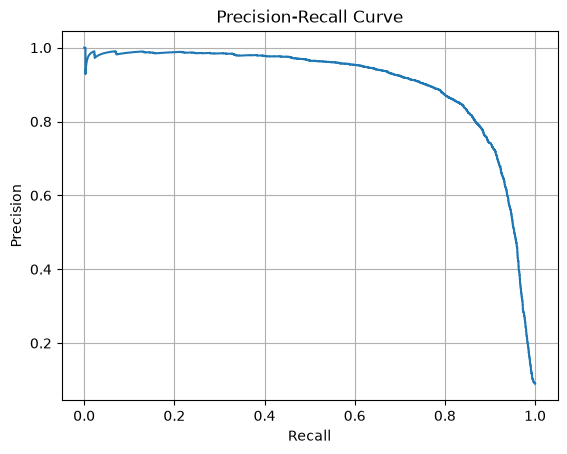

In [38]:
plt.plot(recalls, precisions)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

The Precision-Recall Curve shows the relationship between precision and recall at different decision thresholds.

Generally, as **recall increases, precision decreases**, showing the precision/recall trade-off.

The curve helps us choose an appropriate decision threshold depending on whether we want to prioritize precision, recall, or a balance between both.

## ROC Curve

The ROC (Receiver Operating Characteristic) curve shows the relationship between the true positive rate (recall) and the false positive rate at different decision thresholds.

It helps evaluate how well the classifier separates 5s from non-5s.

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(y_train_5, y_scores)

print("Number of thresholds:", len(thresholds_roc))

Number of thresholds: 2208


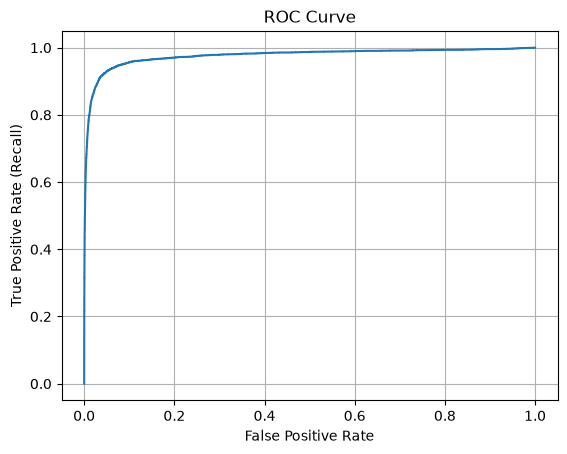

In [40]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.grid()
plt.show()

In [41]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_train_5, y_scores)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9761136438859874


AUC (Area Under the Curve) summarizes the ROC curve into a single value.

The ROC AUC of the SGD classifier is **0.9761**, or approximately **97.61%**.

This indicates that the classifier has a very strong ability to distinguish between images of **5** and images that are **not 5**.

A value close to **1.0** indicates excellent classification performance, while a value close to **0.5** represents performance similar to random guessing.

Therefore, the ROC AUC shows that the SGD classifier is very good at separating 5s from non-5s.

## ROC Curve vs Precision-Recall Curve

The ROC curve and Precision-Recall curve evaluate the classifier from different perspectives.

### ROC Curve

The ROC curve plots **True Positive Rate (Recall)** against **False Positive Rate (FPR)**. It shows how well the classifier separates 5s from non-5s across different decision thresholds.

The ROC AUC of our classifier is **0.9761**, indicating excellent overall separation between the two classes.

### Precision-Recall Curve

The Precision-Recall curve plots **Precision** against **Recall**. It focuses on the performance of the positive class, which is the digit **5** in our binary classification problem.

The Precision-Recall curve is particularly useful when the positive class is relatively rare.

In our training data, there are **4,502 images of 5** and **45,498 images that are not 5**.

Therefore, the Precision-Recall curve provides useful information about how accurately the classifier identifies the relatively rare class of 5s.

## Multiclass Classification

The MNIST dataset contains ten classes, representing the digits from **0 to 9**.

Unlike binary classification, where there are only two possible classes, multiclass classification allows the model to choose between more than two classes.

We will train the SGD classifier using the original MNIST labels so that it can classify images into the ten digit classes.

In [42]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [43]:
y_train_pred = sgd_clf.predict(x_train)

print("Actual:", y_train[:10])
print("Predicted:", y_train_pred[:10])

Actual: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']
Predicted: ['9' '5' '3' '8' '3' '8' '4' '1' '1' '3']


In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_train, y_train_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8947


In [45]:
from sklearn.model_selection import cross_val_score

cross_val_score(
    sgd_clf,
    x_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

array([0.86656267, 0.87748245, 0.87675507])

In [46]:
cv_scores = cross_val_score(
    sgd_clf,
    x_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

CV Scores: [0.86656267 0.87748245 0.87675507]
Mean Accuracy: 0.873600063100142


The SGD classifier achieved the following accuracy scores using 3-fold cross-validation:

- **Fold 1:** 86.66%
- **Fold 2:** 87.75%
- **Fold 3:** 87.68%
- **Mean Accuracy:** 87.36%

The mean cross-validation accuracy of **87.36%** provides a better estimate of the model's ability to generalize to unseen data than the training accuracy alone.

The training accuracy was **89.47%**, which is slightly higher than the cross-validation accuracy.

In [47]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    x_train,
    y_train,
    cv=3
)

In [48]:
from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(y_train, y_train_pred)

print(conf_mx)

[[4617    1   26   47   17  100   50    5   61   15]
 [   2 5415   48   36   11   60   20   15   39    3]
 [  46   62 4271  119   54   33   89   88  188   14]
 [  18   21  156 4239   27  410   22   70  113   55]
 [  14   21   38   14 4445   26   64   59   59  122]
 [  40   19   36  112   98 3926   93   25   97   56]
 [  29   13   42    6   29   96 4678    7   34    3]
 [  15   15   49   44   68   31    6 4758   40  179]
 [  30  177  102  250   78  386   44   50 3665   90]
 [  16   27   19  106  334  133    7  549   82 3666]]


The confusion matrix shows the classification performance of the SGD classifier across all ten digit classes.

The **rows represent the actual digits**, while the **columns represent the predicted digits**.

The values along the **diagonal** represent correct predictions, while the values outside the diagonal represent incorrect predictions.

The classifier performs relatively well on digits such as **1, 6, and 7**, which have high numbers of correct predictions.

Digits such as **5, 8, and 9** are more difficult for the classifier and have more misclassifications.

Some notable confusions include:

- **386 actual 8s were predicted as 5**
- **549 actual 9s were predicted as 7**
- **410 actual 3s were predicted as 5**
- **334 actual 9s were predicted as 4**

The confusion matrix therefore provides more detailed information than accuracy alone by showing which digits the classifier confuses with one another.

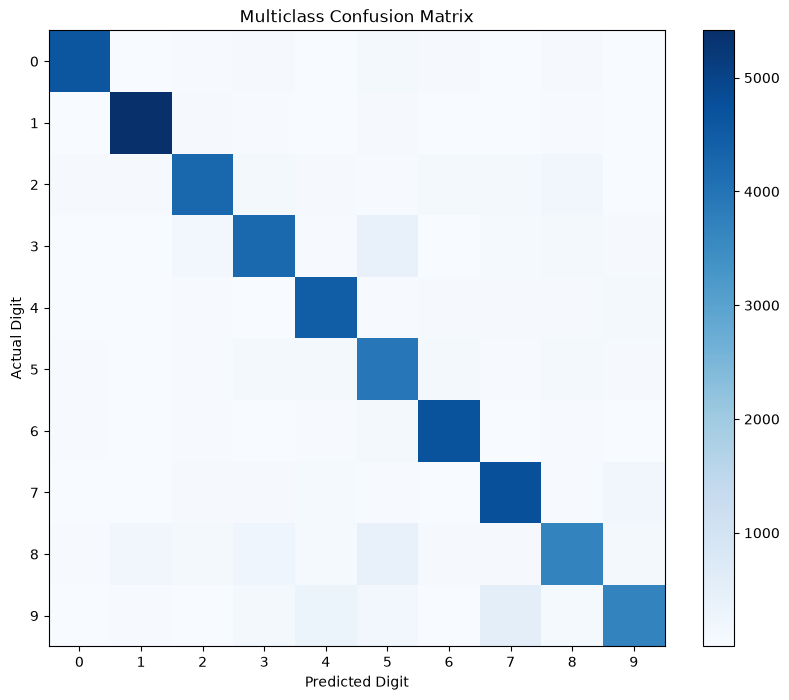

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(conf_mx, cmap="Blues")

plt.colorbar()

plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Multiclass Confusion Matrix")

plt.show()

## Normalize the Confusion Matrix

Normalize the confusion matrix by dividing each row by the total number of actual examples of that digit.

This converts the raw counts into proportions, making it easier to compare the classification performance of different digit classes.

A normalized confusion matrix shows the percentage of each actual digit that was classified as each possible digit.

In [50]:
norm_conf_mx = conf_mx / conf_mx.sum(axis=1, keepdims=True)

print(norm_conf_mx)

[[9.34804616e-01 2.02470136e-04 5.26422353e-03 9.51609638e-03
  3.44199231e-03 2.02470136e-02 1.01235068e-02 1.01235068e-03
  1.23506783e-02 3.03705203e-03]
 [3.54044964e-04 9.58576739e-01 8.49707913e-03 6.37280935e-03
  1.94724730e-03 1.06213489e-02 3.54044964e-03 2.65533723e-03
  6.90387679e-03 5.31067446e-04]
 [9.26672039e-03 1.24899275e-02 8.60394843e-01 2.39726027e-02
  1.08783239e-02 6.64786463e-03 1.79290894e-02 1.77276390e-02
  3.78726833e-02 2.82030620e-03]
 [3.50808809e-03 4.09276944e-03 3.04034301e-02 8.26154746e-01
  5.26213214e-03 7.99064510e-02 4.28766322e-03 1.36425648e-02
  2.20229975e-02 1.07191581e-02]
 [2.87947347e-03 4.31921020e-03 7.81571370e-03 2.87947347e-03
  9.14232826e-01 5.34759358e-03 1.31633073e-02 1.21349239e-02
  1.21349239e-02 2.50925545e-02]
 [8.88494003e-03 4.22034651e-03 7.99644602e-03 2.48778321e-02
  2.17681031e-02 8.72056864e-01 2.06574856e-02 5.55308752e-03
  2.15459796e-02 1.24389160e-02]
 [5.87401256e-03 2.63317804e-03 8.50719060e-03 1.21531294e

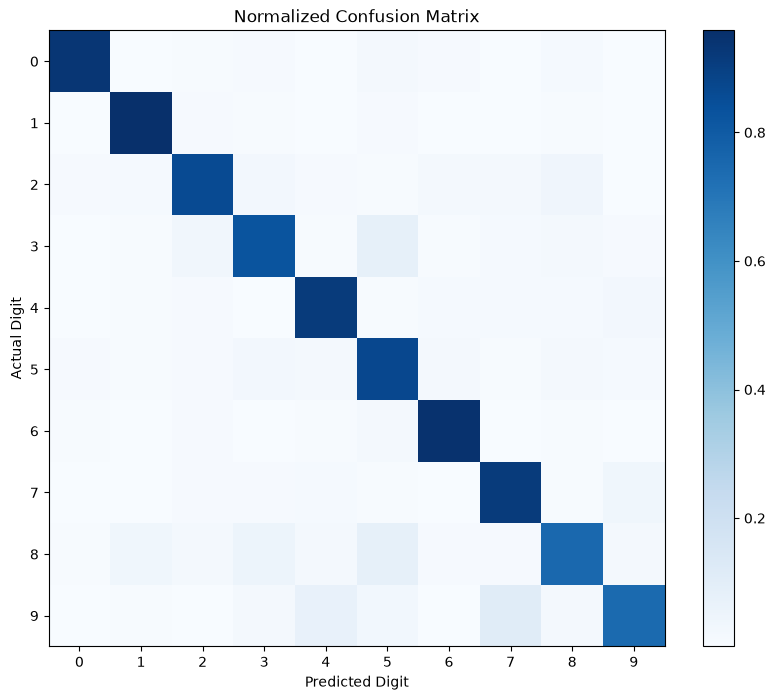

In [51]:
plt.figure(figsize=(10, 8))

plt.imshow(norm_conf_mx, cmap="Blues")

plt.colorbar()

plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Normalized Confusion Matrix")

plt.show()

## Visualize Classification Errors

Remove the correct predictions from the confusion matrix so that only classification errors remain.

This makes it easier to identify which digits are commonly confused with each other.

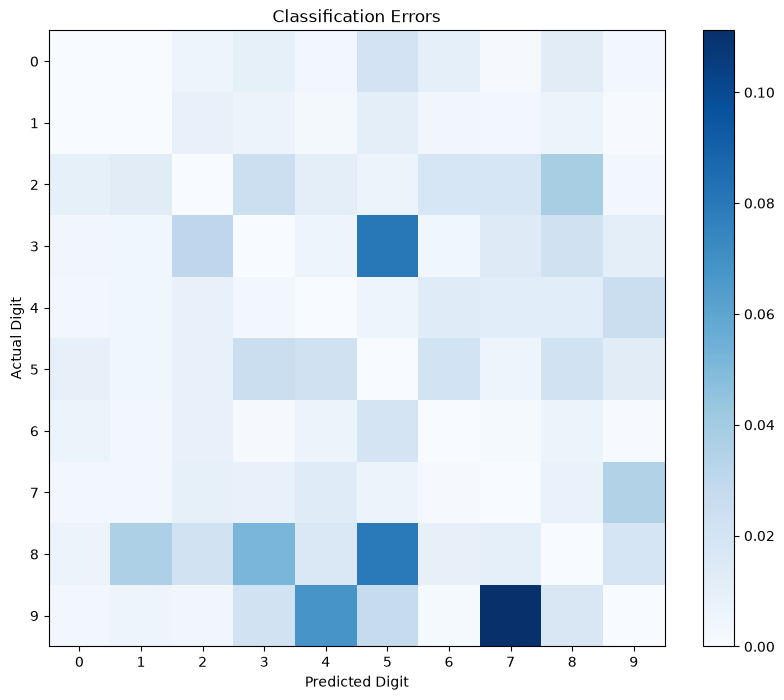

In [52]:
norm_conf_mx_errors = norm_conf_mx.copy()

np.fill_diagonal(norm_conf_mx_errors, 0)

plt.figure(figsize=(10, 8))

plt.imshow(norm_conf_mx_errors, cmap="Blues")

plt.colorbar()

plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Classification Errors")

plt.show()

## Classification Performance by Digit

Calculate the percentage of correctly classified images for each digit.

This helps us identify which individual digits the classifier recognizes well and which digits are more difficult.

In [53]:
for digit in range(10):
    print(f"Digit {digit}: {norm_conf_mx[digit, digit] * 100:.2f}%")

Digit 0: 93.48%
Digit 1: 95.86%
Digit 2: 86.04%
Digit 3: 82.62%
Digit 4: 91.42%
Digit 5: 87.21%
Digit 6: 94.75%
Digit 7: 91.41%
Digit 8: 75.23%
Digit 9: 74.23%


The results show the percentage of correctly classified images for each digit.

The model performs best on **digit 1 (95.86%)** and performs worst on **digit 9 (74.23%)** and **digit 8 (75.23%)**.

This shows that some digits are easier for the SGD classifier to recognize than others.


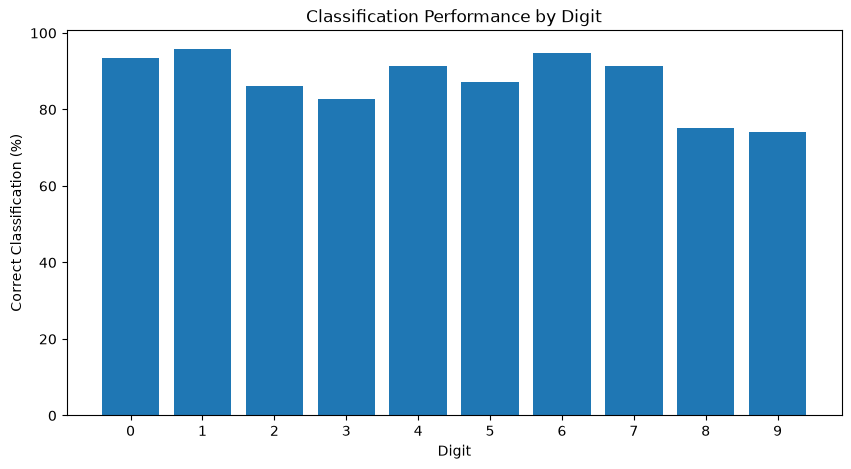

In [54]:
digit_accuracy = [norm_conf_mx[i, i] * 100 for i in range(10)]

plt.figure(figsize=(10, 5))

plt.bar(range(10), digit_accuracy)

plt.xlabel("Digit")
plt.ylabel("Correct Classification (%)")
plt.title("Classification Performance by Digit")

plt.xticks(range(10))

plt.show()

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_train, y_train_pred, average="weighted")
recall = recall_score(y_train, y_train_pred, average="weighted")
f1 = f1_score(y_train, y_train_pred, average="weighted")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8750829161561113
Recall: 0.8736
F1 Score: 0.8729171631861395


## Multiclass SGDClassifier Evaluation

The SGD classifier achieved the following results:

- **Accuracy:** 87.36%
- **Precision:** 87.51%
- **Recall:** 87.36%
- **F1 Score:** 87.29%

These results show that the SGD classifier provides a good baseline for the multiclass MNIST classification problem.

We will compare these results with other classification algorithms before selecting the final model.

## Logistic Regression

Train a Logistic Regression classifier for the multiclass MNIST classification problem.

Logistic Regression can be extended to multiclass classification and will be evaluated against the SGD classifier.

### Logistic Regression with Feature Scaling

Use a Pipeline to scale the MNIST pixel values before training the Logistic Regression classifier.

Feature scaling helps the optimization algorithm converge more effectively.

In [56]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=300,
        random_state=42
    )
)

log_reg_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [57]:
y_train_pred_log = log_reg_pipeline.predict(x_train)

print("Actual:", y_train[:10])
print("Predicted:", y_train_pred_log[:10])

Actual: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']
Predicted: ['9' '5' '1' '8' '3' '8' '4' '1' '1' '3']


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_log = accuracy_score(y_train, y_train_pred_log)

precision_log = precision_score(
    y_train,
    y_train_pred_log,
    average="weighted"
)

recall_log = recall_score(
    y_train,
    y_train_pred_log,
    average="weighted"
)

f1_log = f1_score(
    y_train,
    y_train_pred_log,
    average="weighted"
)

print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1 Score:", f1_log)

Accuracy: 0.94452
Precision: 0.9444156035994319
Recall: 0.94452
F1 Score: 0.9444525560487705


## Logistic Regression Cross-Validation

Use 3-fold cross-validation to evaluate the Logistic Regression classifier on different parts of the training data.

Cross-validation helps estimate how well the model generalizes to unseen data.

In [59]:
from sklearn.model_selection import cross_val_score

log_cv_scores = cross_val_score(
    log_reg_pipeline,
    x_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("CV Scores:", log_cv_scores)
print("Mean Accuracy:", log_cv_scores.mean())

CV Scores: [0.90256195 0.90322194 0.9024961 ]
Mean Accuracy: 0.9027599947221024


## K-Nearest Neighbors

Train a K-Nearest Neighbors (KNN) classifier for the multiclass MNIST classification problem.

KNN classifies an image by comparing it with nearby training examples and assigning the class that is most common among its nearest neighbors.

In [60]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(
    n_neighbors=3
)

knn_clf.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [61]:
y_train_pred_knn = knn_clf.predict(x_train)

print("Actual:", y_train[:10])
print("Predicted:", y_train_pred_knn[:10])

Actual: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']
Predicted: ['9' '5' '1' '8' '9' '8' '4' '1' '1' '3']


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_train, y_train_pred_knn)

precision_knn = precision_score(
    y_train,
    y_train_pred_knn,
    average="weighted"
)

recall_knn = recall_score(
    y_train,
    y_train_pred_knn,
    average="weighted"
)

f1_knn = f1_score(
    y_train,
    y_train_pred_knn,
    average="weighted"
)

print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1 Score:", f1_knn)

Accuracy: 0.98582
Precision: 0.9858789335385876
Recall: 0.98582
F1 Score: 0.9858048690504954


In [63]:
from sklearn.model_selection import cross_val_score

knn_cv_scores = cross_val_score(
    knn_clf,
    x_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("CV Scores:", knn_cv_scores)
print("Mean Accuracy:", knn_cv_scores.mean())

CV Scores: [0.96736065 0.96808064 0.96807872]
Mean Accuracy: 0.9678400047743675


## Decision Tree

Train a Decision Tree classifier for the multiclass MNIST classification problem.

A Decision Tree makes predictions by learning a sequence of decision rules from the training data.

In [64]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(
    random_state=42
)

tree_clf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [65]:
y_train_pred_tree = tree_clf.predict(x_train)

print("Actual:", y_train[:10])
print("Predicted:", y_train_pred_tree[:10])

Actual: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']
Predicted: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']


In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_tree = accuracy_score(y_train, y_train_pred_tree)

precision_tree = precision_score(
    y_train,
    y_train_pred_tree,
    average="weighted"
)

recall_tree = recall_score(
    y_train,
    y_train_pred_tree,
    average="weighted"
)

f1_tree = f1_score(
    y_train,
    y_train_pred_tree,
    average="weighted"
)

print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1 Score:", f1_tree)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [67]:
from sklearn.model_selection import cross_val_score

tree_cv_scores = cross_val_score(
    tree_clf,
    x_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("CV Scores:", tree_cv_scores)
print("Mean Accuracy:", tree_cv_scores.mean())

CV Scores: [0.85222296 0.85366293 0.85947438]
Mean Accuracy: 0.8551200870858379


The Decision Tree achieved **100% training accuracy** but only **85.51% cross-validation accuracy**.

This large difference shows that the model **overfits the training data**.

Therefore, the Decision Tree is not currently the best model for our MNIST classification problem.

We will compare it with other algorithms before selecting the final model.

## Random Forest

Train a Random Forest classifier for the multiclass MNIST classification problem.

Random Forest combines multiple decision trees to make predictions and can reduce the overfitting problem of a single Decision Tree.

In [68]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_clf.fit(x_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [69]:
y_train_pred_forest = forest_clf.predict(x_train)

print("Actual:", y_train[:10])
print("Predicted:", y_train_pred_forest[:10])

Actual: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']
Predicted: ['8' '5' '1' '8' '9' '8' '4' '1' '1' '3']


In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_forest = accuracy_score(y_train, y_train_pred_forest)

precision_forest = precision_score(
    y_train,
    y_train_pred_forest,
    average="weighted"
)

recall_forest = recall_score(
    y_train,
    y_train_pred_forest,
    average="weighted"
)

f1_forest = f1_score(
    y_train,
    y_train_pred_forest,
    average="weighted"
)

print("Accuracy:", accuracy_forest)
print("Precision:", precision_forest)
print("Recall:", recall_forest)
print("F1 Score:", f1_forest)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [71]:
from sklearn.model_selection import cross_val_score

forest_cv_scores = cross_val_score(
    forest_clf,
    x_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("CV Scores:", forest_cv_scores)
print("Mean Accuracy:", forest_cv_scores.mean())

CV Scores: [0.96358073 0.96346073 0.96303852]
Mean Accuracy: 0.9633599935705593


## Model Comparison

Compare the performance of the classification algorithms using cross-validation accuracy and training accuracy.

| Model | CV Mean Accuracy | Training Accuracy | Observation |
|---|---:|---:|---|
| SGDClassifier | 87.36% | 89.47% | Good baseline |
| Logistic Regression | 90.28% | 94.45% | Good performance |
| Decision Tree | 85.51% | 100% | Strong overfitting |
| Random Forest | 96.34% | 100% | Excellent |
| **KNN** | **96.78%** | **98.58%** | **Best CV performance** |

KNN currently has the highest cross-validation accuracy and is the leading candidate for the final model.

## Final Model Test Evaluation

Evaluate the selected KNN classifier on the untouched test dataset.

The test dataset was kept separate from model training and model selection, so this evaluation provides the final estimate of how well the model performs on unseen MNIST images.

In [72]:
y_test_pred_knn = knn_clf.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred_knn))

print("Test Precision:", precision_score(
    y_test,
    y_test_pred_knn,
    average="weighted"
))

print("Test Recall:", recall_score(
    y_test,
    y_test_pred_knn,
    average="weighted"
))

print("Test F1 Score:", f1_score(
    y_test,
    y_test_pred_knn,
    average="weighted"
))

Test Accuracy: 0.969
Test Precision: 0.969225128753115
Test Recall: 0.969
Test F1 Score: 0.968936204061489


In [73]:
import joblib

joblib.dump(knn_clf, "mnist_knn_model.pkl")

print("KNN model saved successfully.")

KNN model saved successfully.


In [74]:
import joblib

loaded_knn = joblib.load("mnist_knn_model.pkl")

y_test_pred_loaded = loaded_knn.predict(x_test)

print("Predictions match:", (y_test_pred_loaded == y_test_pred_knn).all())

Predictions match: True


#### Make a Prediction with the Saved Model

Use the saved KNN model to classify an MNIST image from the test dataset.

The model will predict which digit the image represents.

In [90]:
image = x_test[10]

prediction = loaded_knn.predict([image])

print("Predicted digit:", prediction[0])
print("Actual digit:", y_test[10])

Predicted digit: 0
Actual digit: 0


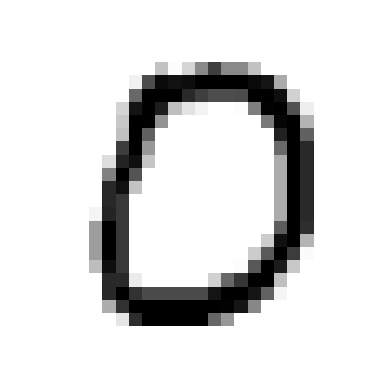

Predicted digit: 0
Actual digit: 0


In [91]:
import matplotlib.pyplot as plt

plt.imshow(image.reshape(28, 28), cmap="binary")
plt.axis("off")
plt.show()

print("Predicted digit:", prediction[0])
print("Actual digit:", y_test[10])